In [1]:
# Introduction to feature selection engineering

In [3]:
# Feature Selection: Process of idetifying and retaining the most relevant features(input variables) in a dataset while discrading irrevelant or redundant ones

# these step will help in reducing overfitting, Simplifiy the model, improve competional efficiency

In [4]:
# importance of feature selection
    # -improves model performance: relevant features can introduce noise so feature selection is important for model performance
    # -reduce overfitting:simplifing the model will give better unseen or betterpredicted data
    # -Enchances interpretability: a smaller of set of relevant features makes the model easier to understand
    # -increases computational efficiency: reduces a time and resources need for training and other

In [6]:
# when to use Feature Selection:
    # -High-Dimensional Data
    # -Correlated features
    # -reduce complexity

In [10]:
# Techniques for feature Selection
# 1.Filter Methods: Evaluate the relevance of features by analyzing their statistical properties in relation to target variables
    # Examples: Correlation | Mutual Information
    # Whne to use: Quick evaluation of features before training a model

# 2. Wrapper Model: Iteratively Selects features by training and evaluating a model
    # ex: Forward Selection | Backward selection
    # When to use: Useful when feature interactions are important but computationally expensive

# 3. Embedded Methods:Perform feature selection as part of the model training process
    # ex: Lasso Regression | Tree-Based model
    # when to use: effective when training tree-based models or regularized regression
    

In [11]:
# excerise

In [12]:
# Use correlation and mutual information to select important features from a datasset
# Apply a tree-based model(eg: random forest) to identify the most important features

        age       sex       bmi        bp  ...        s4        s5        s6  target
0  0.038076  0.050680  0.061696  0.021872  ... -0.002592  0.019907 -0.017646   151.0
1 -0.001882 -0.044642 -0.051474 -0.026328  ... -0.039493 -0.068332 -0.092204    75.0
2  0.085299  0.050680  0.044451 -0.005670  ... -0.002592  0.002861 -0.025930   141.0
3 -0.089063 -0.044642 -0.011595 -0.036656  ...  0.034309  0.022688 -0.009362   206.0
4  0.005383 -0.044642 -0.036385  0.021872  ... -0.002592 -0.031988 -0.046641   135.0

[5 rows x 11 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    

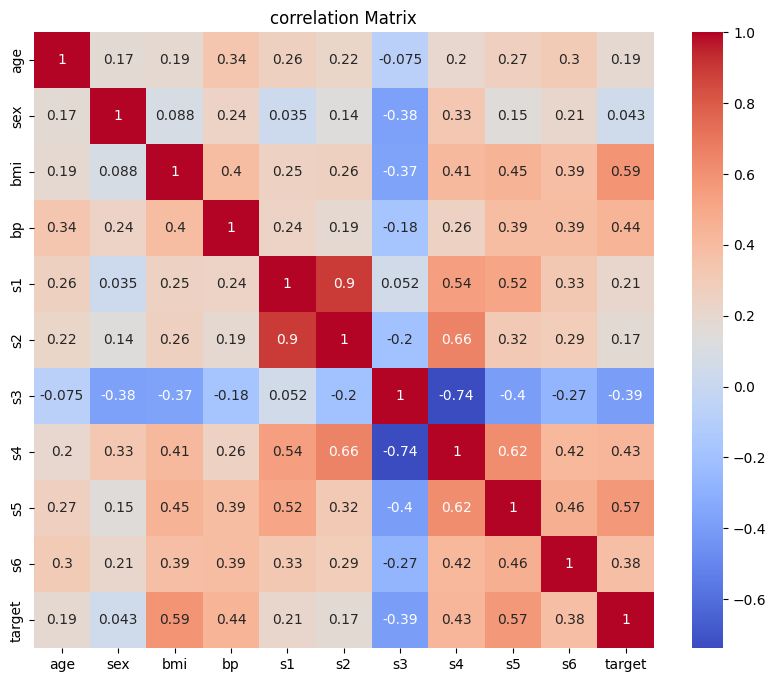

features most correlated targets
target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64
Mutual Information:
[0.         0.03877148 0.17176467 0.04995445 0.06733165 0.01335682
 0.07266563 0.09877589 0.14975722 0.10547054]
mutual Information scores
  Feature  Mutual Information
2     bmi            0.171765
8      s5            0.149757
9      s6            0.105471
7      s4            0.098776
6      s3            0.072666
4      s1            0.067332
3      bp            0.049954
1     sex            0.038771
5      s2            0.013357
0     age            0.000000


In [22]:
from sklearn.feature_selection import mutual_info_regression
# dataset: Diabets dataset
from sklearn.datasets import load_diabetes
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

# load the dataset
data = load_diabetes()
df=pd.DataFrame(data.data, columns=data.feature_names)
df['target']=data.target

# display dataset infortmation
print(df.head())
print(df.info())

# calculate correlation matrix
correlation_matrix=df.corr()

# plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("correlation Matrix")
plt.show()

# select features with high correlation to the target
correlated_features=correlation_matrix['target'].sort_values(ascending=False)
print("features most correlated targets")
print(correlated_features)


# seperate features and target
X=df.drop(columns=['target'], axis=1)
y=df['target']

# calculate mutual information
mutual_info = mutual_info_regression(X, y)
print("Mutual Information:")
print(mutual_info)

# create a dataframe for better visualization
mi_df=pd.DataFrame({'Feature':X.columns, "Mutual Information":mutual_info})
mi_df=mi_df.sort_values(by="Mutual Information", ascending=False)
print("mutual Information scores")
print(mi_df)

feature importance from random forest
  Feature  importance
8      s5    0.315629
2     bmi    0.276249
3      bp    0.087085
9      s6    0.070775
0     age    0.057496
5      s2    0.055368
6      s3    0.051191
4      s1    0.047251
7      s4    0.027056
1     sex    0.011901


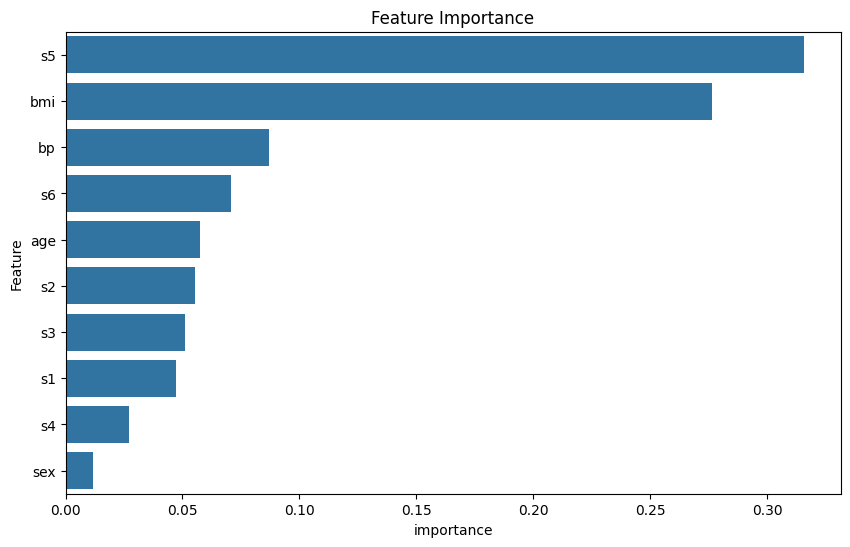

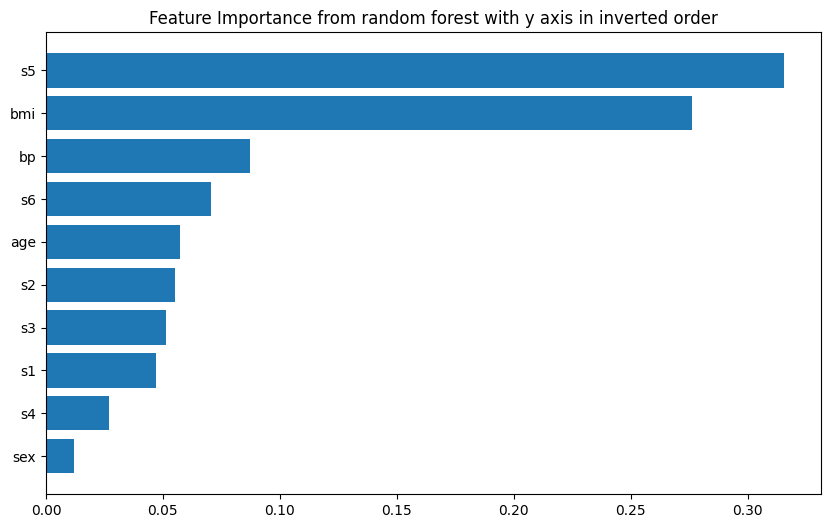

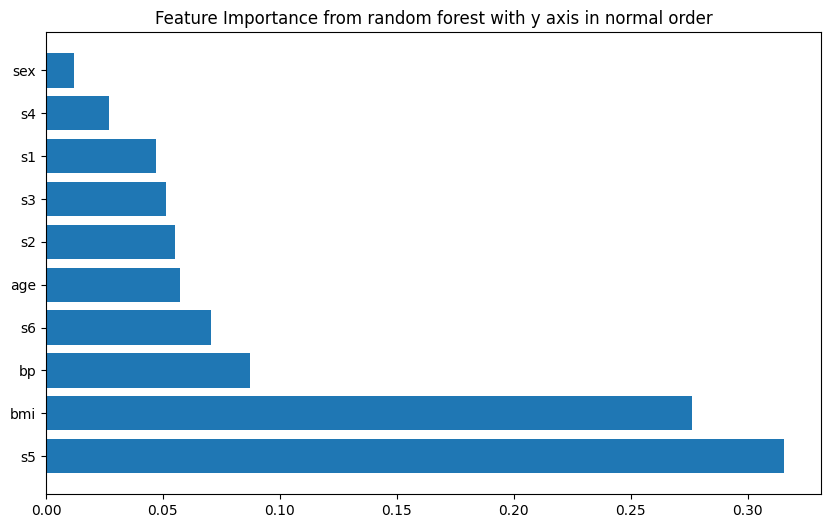

In [31]:
# feature selection using tree based algorithm
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Train a random forest model
model=RandomForestRegressor(random_state=42)
model.fit(X,y)

# Get feature importance
feature_importance = model.feature_importances_
importance_df = pd.DataFrame({'Feature':X.columns,"importance":feature_importance})
importance_df = importance_df.sort_values(by="importance",ascending=False)

print("feature importance from random forest")
print(importance_df)

# plot features importance
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(x="importance",y="Feature",data=importance_df)
plt.title("Feature Importance")
plt.show()

plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'],importance_df['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance from random forest with y axis in inverted order")
plt.show()

plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'],importance_df['importance'])
# plt.gca().invert_yaxis()
plt.title("Feature Importance from random forest with y axis in normal order")
plt.show()